#  FaceNet — Identification sur LFW
### IMT Nord Europe — Projet Biométrie
---

In [ ]:
# ── Cellule 1 : Installation ─────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "uninstall", "facenet-pytorch", "-y", "-q"])
subprocess.run([sys.executable, "-m", "pip", "install", "facenet-pytorch", "--no-deps", "-q"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "requests", "Pillow", "-q"], check=True)
print(" Installation OK → fais Restart & Run All")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 27.7 MB/s eta 0:00:00
✅ Installation OK → fais Restart & Run All


In [ ]:
# ── Cellule 2 : Imports & configuration ──────────────────────────────
import os, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from tqdm import tqdm

import torch
from PIL import Image

from facenet_pytorch import MTCNN, InceptionResnetV1
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Device  : {DEVICE}")
print(f"   NumPy   : {np.__version__}")
print(f"   PyTorch : {torch.__version__}")

✅ Device  : cpu
   NumPy   : 2.0.2
   PyTorch : 2.10.0+cpu


In [ ]:
# ── Cellule 3 : Détection automatique du chemin LFW ──────────────────
MIN_IMAGES = 10

def find_lfw_root(base="/kaggle/input"):
    base = Path(base)
    if not base.exists():
        return None
    for path in sorted(base.rglob("*")):
        if path.is_dir():
            subdirs = [x for x in path.iterdir() if x.is_dir()]
            if len(subdirs) > 100:
                sample = subdirs[0]
                if list(sample.glob("*.jpg")):
                    return path
    return None

print(" Contenu de /kaggle/input :")
for p in sorted(Path("/kaggle/input").rglob("*")):
    depth = len(p.relative_to("/kaggle/input").parts)
    if depth <= 4:
        print("  " * depth + p.name + ("/" if p.is_dir() else ""))

RAW_DATA_DIR = find_lfw_root("/kaggle/input")
if RAW_DATA_DIR is None:
    raise FileNotFoundError("❌ Dataset LFW introuvable dans /kaggle/input.")
print(f"\n Racine LFW détectée : {RAW_DATA_DIR}")

📂 Contenu de /kaggle/input :
  datasets/
    jessicali9530/
      lfw-dataset/
        lfw-deepfunneled/
        lfw_allnames.csv
        lfw_readme.csv
        matchpairsDevTest.csv
        matchpairsDevTrain.csv
        mismatchpairsDevTest.csv
        mismatchpairsDevTrain.csv
        pairs.csv
        people.csv
        peopleDevTest.csv
        peopleDevTrain.csv

✅ Racine LFW détectée : /kaggle/input/datasets/jessicali9530/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled


✅ 158 personnes | 4324 images
   Min images / personne  : 10
   + d'images : George_W_Bush (530 imgs)
   - d'images : Bill_McBride (10 imgs)


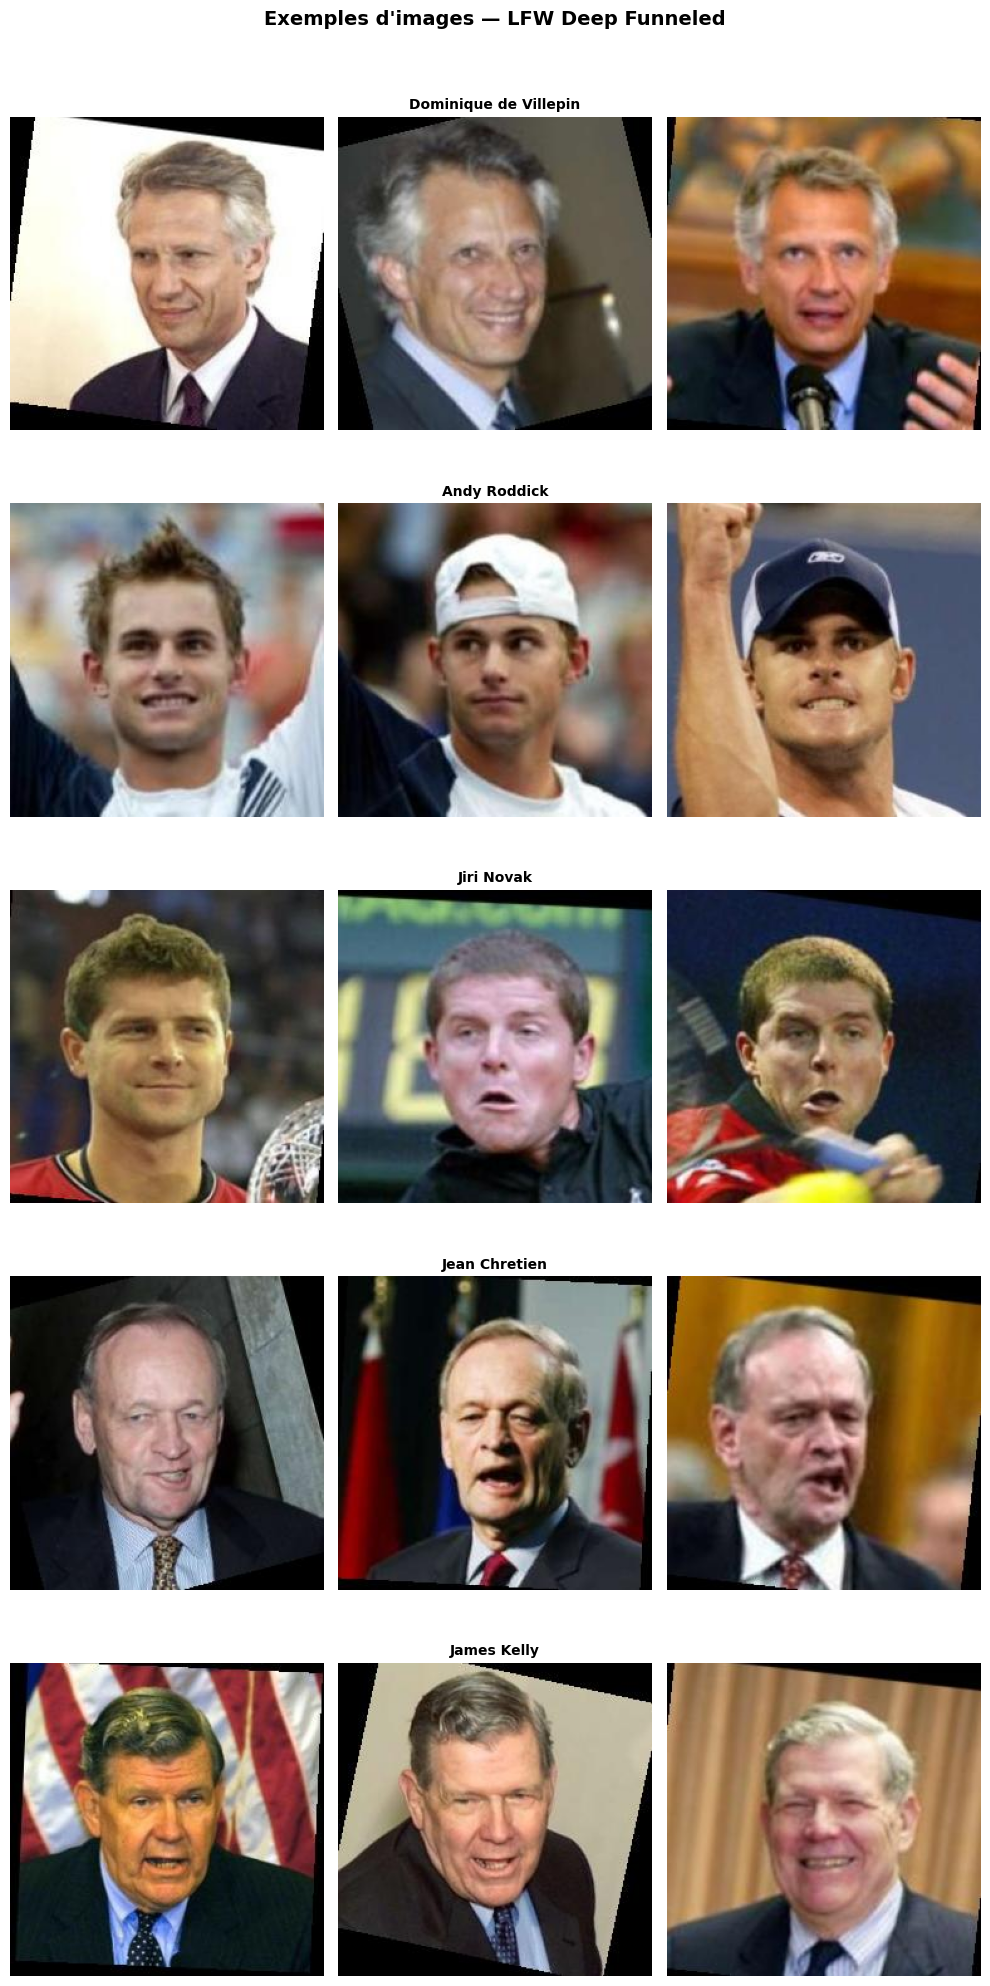

In [ ]:
# ── Cellule 4 : Chargement + visualisation des exemples ──────────────
def load_lfw_paths(root: Path, min_images: int):
    paths, labels = [], []
    for person_dir in sorted(root.iterdir()):
        if not person_dir.is_dir():
            continue
        imgs = sorted(person_dir.glob("*.jpg"))
        if len(imgs) >= min_images:
            for img in imgs:
                paths.append(img)
                labels.append(person_dir.name)
    return paths, labels

paths, labels = load_lfw_paths(RAW_DATA_DIR, MIN_IMAGES)
unique_labels = sorted(set(labels))
counts = Counter(labels)

print(f" {len(unique_labels)} personnes | {len(paths)} images")
print(f"   Min images / personne  : {MIN_IMAGES}")
print(f"   + d'images : {max(counts, key=counts.get)} ({max(counts.values())} imgs)")
print(f"   - d'images : {min(counts, key=counts.get)} ({min(counts.values())} imgs)")

# ── Visualisation ────────────────────────────────────────────────────
random.seed(42)
sample_persons = random.sample(unique_labels, min(5, len(unique_labels)))

fig, axes = plt.subplots(len(sample_persons), 3, figsize=(10, 4 * len(sample_persons)))
for row, person in enumerate(sample_persons):
    person_imgs = [p for p, l in zip(paths, labels) if l == person]
    chosen = random.sample(person_imgs, min(3, len(person_imgs)))
    for col in range(3):
        ax = axes[row, col]
        if col < len(chosen):
            ax.imshow(Image.open(chosen[col]))
            ax.set_title(person.replace('_', ' ') if col == 1 else "", fontsize=10, fontweight='bold')
        ax.axis('off')
plt.suptitle("Exemples d'images — LFW Deep Funneled", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ── Cellule 5 : Initialisation MTCNN + FaceNet ───────────────────────
mtcnn = MTCNN(image_size=160, margin=20, keep_all=False, device=DEVICE)
facenet = InceptionResnetV1(pretrained='vggface2').eval().to(DEVICE)
print(" MTCNN et FaceNet chargés — embeddings 512 dimensions")

  0%|          | 0.00/107M [00:00<?, ?B/s]

✅ MTCNN et FaceNet chargés — embeddings 512 dimensions


In [ ]:
# ── Cellule 6 : Extraction des embeddings ────────────────────────────
def extract_embeddings(paths, labels, batch_size=64):
    embeddings, valid_labels, valid_paths = [], [], []
    for i in tqdm(range(0, len(paths), batch_size), desc="Extraction embeddings"):
        batch_paths  = paths[i:i+batch_size]
        batch_labels = labels[i:i+batch_size]
        imgs  = [Image.open(p).convert("RGB") for p in batch_paths]
        faces = mtcnn(imgs)
        valid_imgs, valid_labs, valid_ps = [], [], []
        for face, label, p in zip(faces, batch_labels, batch_paths):
            if face is not None:
                valid_imgs.append(face)
                valid_labs.append(label)
                valid_ps.append(p)
        if not valid_imgs:
            continue
        batch_tensor = torch.stack(valid_imgs).to(DEVICE)
        with torch.no_grad():
            emb = facenet(batch_tensor).cpu().numpy()
        embeddings.append(emb)
        valid_labels.extend(valid_labs)
        valid_paths.extend(valid_ps)
    return np.vstack(embeddings), np.array(valid_labels), valid_paths

X, y, valid_paths = extract_embeddings(paths, labels)
X = normalize(X)
print(f"\n Embeddings : {X.shape}")
print(f"   Visages non détectés par MTCNN : {len(paths) - len(valid_paths)}")

Extraction embeddings: 100%|██████████| 68/68 [06:49<00:00,  6.02s/it]


✅ Embeddings : (4324, 512)
   Visages non détectés par MTCNN : 0


In [ ]:
# ── Cellule 7 : Encodage & split train/test ───────────────────────────
le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test, paths_train, paths_test = train_test_split(
    X, y_enc, valid_paths, test_size=0.2, stratify=y_enc, random_state=42
)
print(f" Train : {X_train.shape[0]} | Test : {X_test.shape[0]} | Classes : {len(le.classes_)}")

✅ Train : 3459 | Test : 865 | Classes : 158


In [ ]:
# ── Cellule 8 : Classifieur SVM ───────────────────────────────────────
print("Entraînement SVM (kernel=linear)...")
clf = SVC(kernel='linear', probability=True, C=1.0)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
acc    = accuracy_score(y_test, y_pred)
print(f"\n Accuracy SVM : {acc*100:.2f}%")
print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))

Entraînement SVM (kernel=linear)...

✅ Accuracy SVM : 98.61%
                           precision    recall  f1-score   support

             Abdullah_Gul       0.80      1.00      0.89         4
             Adrien_Brody       1.00      1.00      1.00         2
         Alejandro_Toledo       1.00      1.00      1.00         8
             Alvaro_Uribe       1.00      1.00      1.00         7
          Amelie_Mauresmo       1.00      1.00      1.00         4
             Andre_Agassi       1.00      1.00      1.00         7
             Andy_Roddick       1.00      1.00      1.00         3
           Angelina_Jolie       1.00      1.00      1.00         4
              Ann_Veneman       1.00      1.00      1.00         2
          Anna_Kournikova       1.00      1.00      1.00         2
            Ari_Fleischer       1.00      1.00      1.00         3
             Ariel_Sharon       1.00      1.00      1.00        16
    Arnold_Schwarzenegger       1.00      1.00      1.00         8


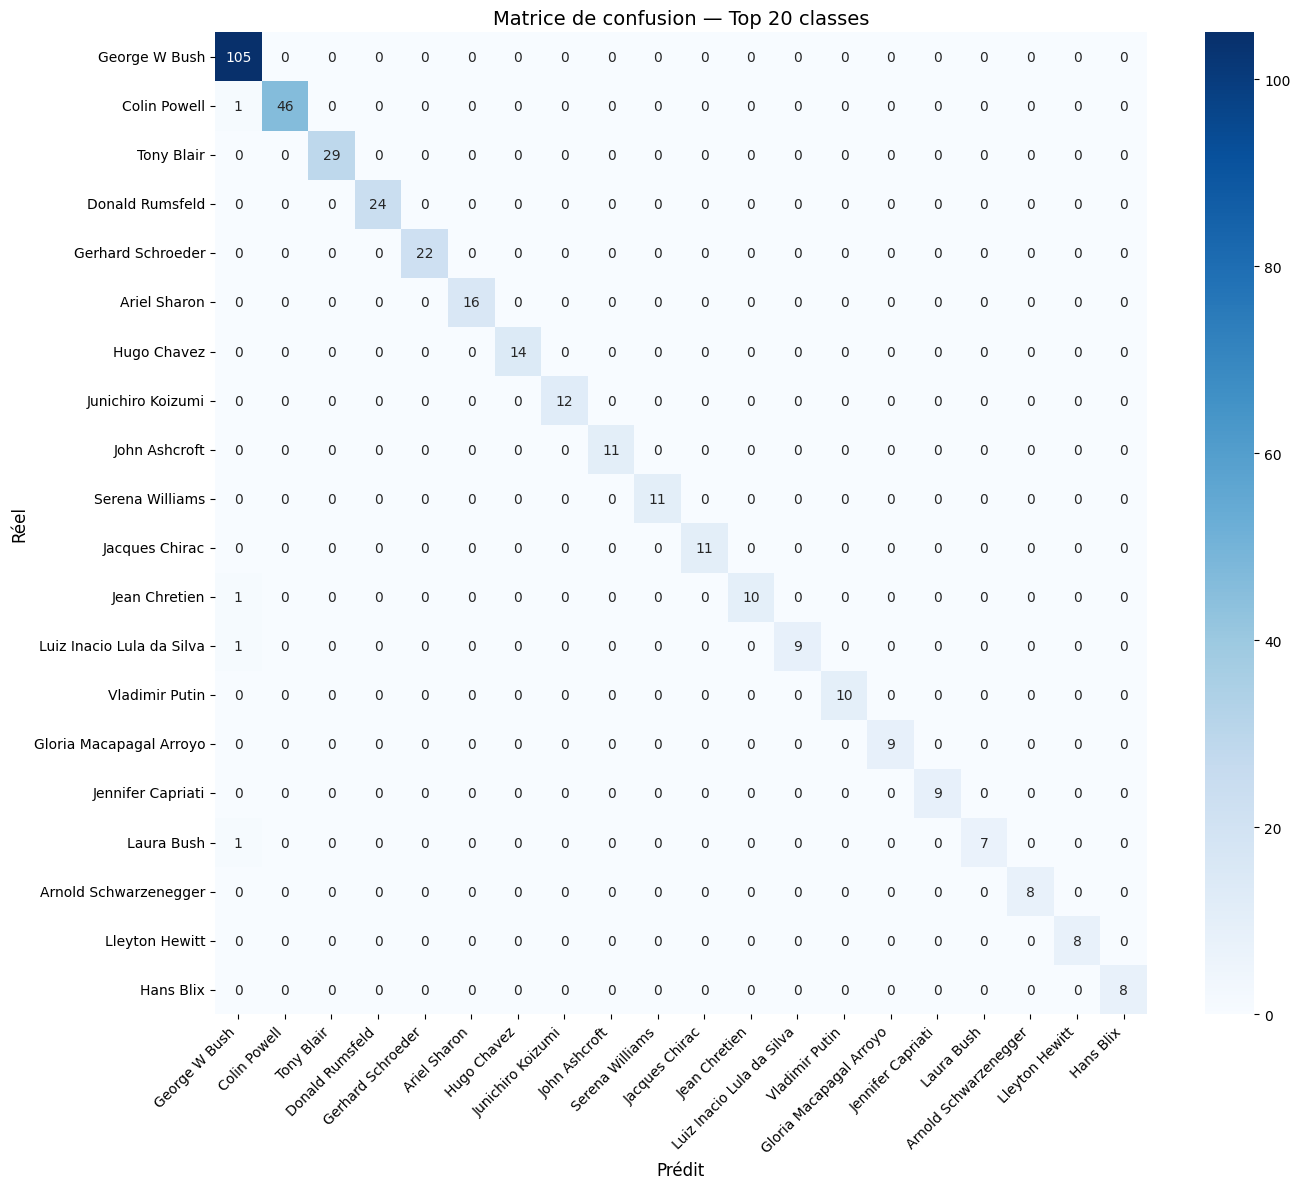


ℹ️  Lignes filtrées (prédit hors top-20) : 383 / 865


In [ ]:
# ── Cellule 9 : Matrice de confusion (top-20 classes) ─────────────────
# FIX : le remap doit aussi couvrir les prédictions hors top-20
# On filtre mask sur y_test ET y_pred tous les deux dans top20

top20_enc   = [enc for enc, _ in Counter(y_test).most_common(20)]
top20_set   = set(top20_enc)
top20_names = le.classes_[top20_enc]

# Garder uniquement les lignes où réel ET prédit sont dans le top-20
mask  = np.array([
    yt in top20_set and yp in top20_set
    for yt, yp in zip(y_test, y_pred)
])
y_t20 = y_test[mask]
y_p20 = y_pred[mask]

remap  = {old: new for new, old in enumerate(top20_enc)}
y_t20r = np.array([remap[v] for v in y_t20])
y_p20r = np.array([remap[v] for v in y_p20])

cm = confusion_matrix(y_t20r, y_p20r, labels=list(range(len(top20_enc))))

# Noms courts pour lisibilité
short_names = [n.replace('_', ' ') for n in top20_names]

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=short_names, yticklabels=short_names, cmap='Blues')
plt.title("Matrice de confusion — Top 20 classes", fontsize=14)
plt.xlabel("Prédit", fontsize=12); plt.ylabel("Réel", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\n Lignes filtrées (prédit hors top-20) : {mask.sum()} / {len(y_test)}")

❌ 12 erreurs sur 865 (1.4%)


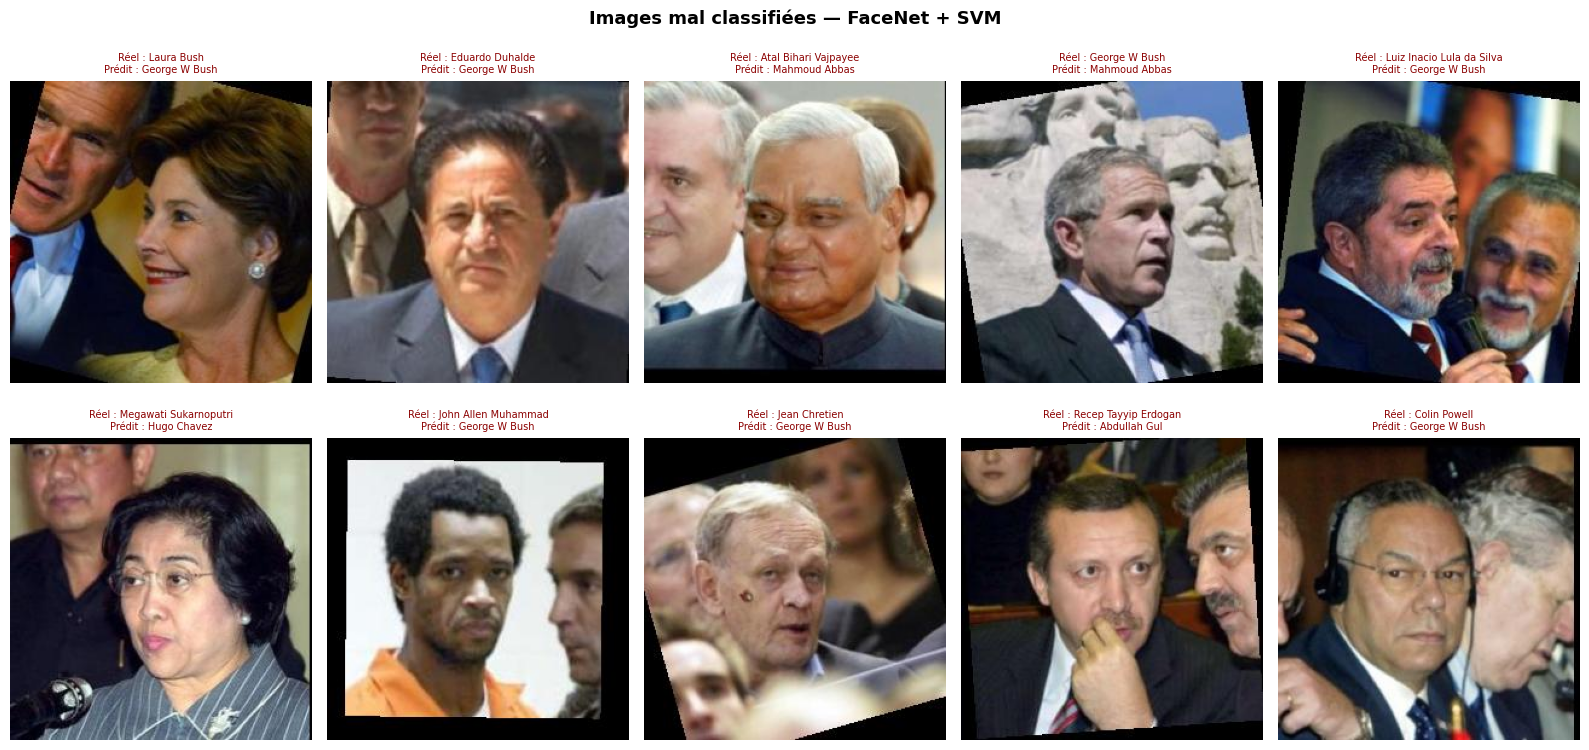

In [ ]:
# ── Cellule 10 : Analyse des erreurs ──────────────────────────────────
errors = np.where(y_test != y_pred)[0]
print(f" {len(errors)} erreurs sur {len(y_test)} ({len(errors)/len(y_test)*100:.1f}%)")

if len(errors) == 0:
    print("🎉 Aucune erreur !")
else:
    n_show = min(10, len(errors))
    cols = 5
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = axes.flatten() if rows > 1 else axes
    for i, err_idx in enumerate(errors[:n_show]):
        true_name = le.classes_[y_test[err_idx]]
        pred_name = le.classes_[y_pred[err_idx]]
        img = Image.open(paths_test[err_idx])
        axes[i].imshow(img)
        axes[i].set_title(
            f"Réel : {true_name.replace('_',' ')}\nPrédit : {pred_name.replace('_',' ')}",
            fontsize=7, color='darkred'
        )
        axes[i].axis('off')
    for i in range(n_show, len(axes)):
        axes[i].axis('off')
    plt.suptitle("Images mal classifiées — FaceNet + SVM", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

Calcul t-SNE sur 343 points (peut prendre ~1 min)...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


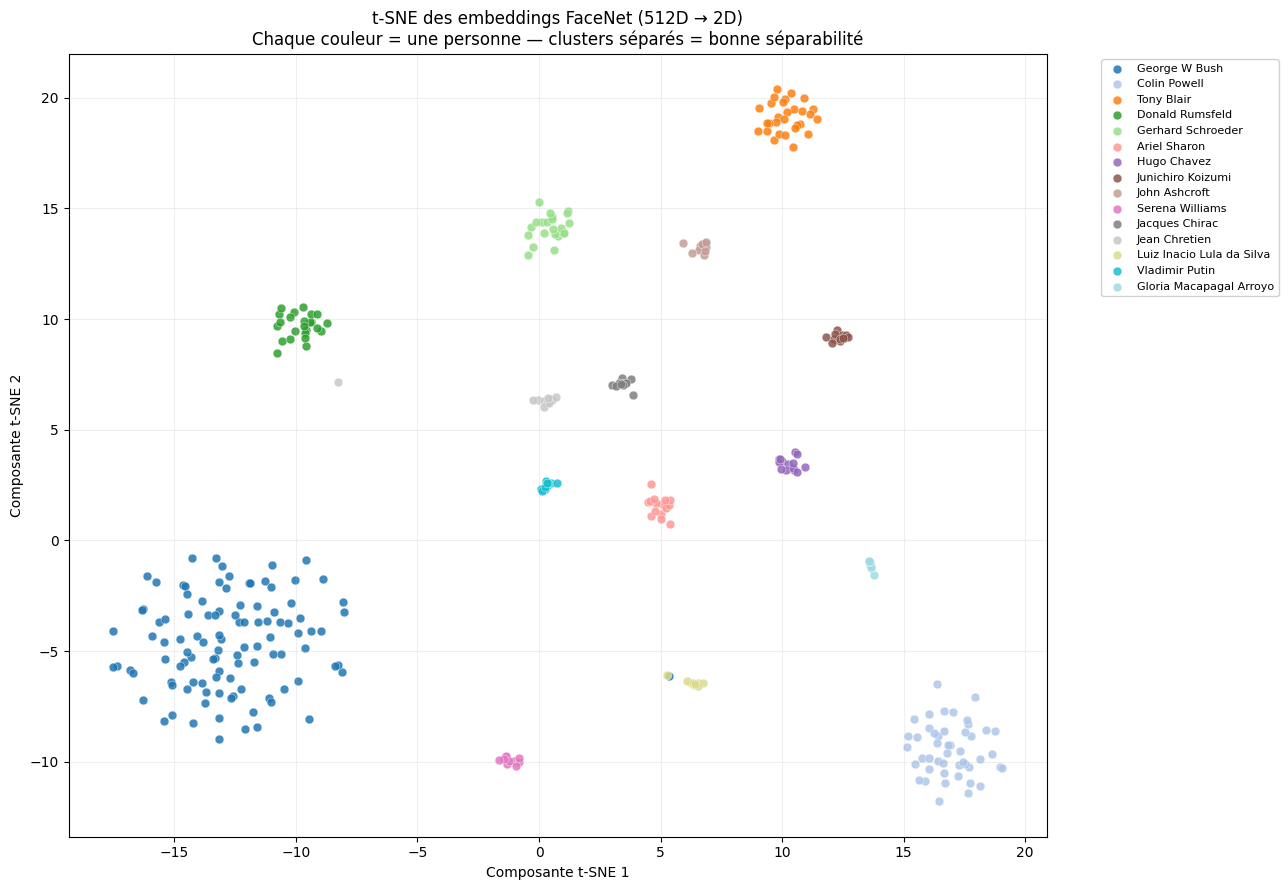


💡 Interprétation :
   • Clusters bien séparés → FaceNet produit des embeddings discriminants
   • Points d'une même couleur groupés → bonne cohérence intra-classe
   • Clusters qui se chevauchent → personnes visuellement similaires


In [ ]:
# ── Cellule 11 : Visualisation t-SNE des embeddings ───────────────────
# t-SNE = réduction de 512 dimensions → 2 dimensions pour visualisation
# Les points proches = embeddings similaires = même personne (idéalement)
from sklearn.manifold import TSNE

top15_enc   = [enc for enc, _ in Counter(y_test).most_common(15)]
top15_names = le.classes_[top15_enc]

mask15 = np.isin(y_test, top15_enc)
X_vis  = X_test[mask15]
y_vis  = y_test[mask15]

print(f"Calcul t-SNE sur {X_vis.shape[0]} points (peut prendre ~1 min)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_2d = tsne.fit_transform(X_vis)

colors = plt.cm.tab20(np.linspace(0, 1, len(top15_enc)))
fig, ax = plt.subplots(figsize=(13, 9))
for i, (enc, name) in enumerate(zip(top15_enc, top15_names)):
    mask_i = y_vis == enc
    ax.scatter(X_2d[mask_i, 0], X_2d[mask_i, 1],
               label=name.replace('_', ' '), s=40, alpha=0.85, color=colors[i], edgecolors='white', linewidths=0.3)

ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, framealpha=0.9)
ax.set_title(
    "t-SNE des embeddings FaceNet (512D → 2D)\n"
    "Chaque couleur = une personne — clusters séparés = bonne séparabilité",
    fontsize=12
)
ax.set_xlabel("Composante t-SNE 1")
ax.set_ylabel("Composante t-SNE 2")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print("\n Interprétation :")
print("   • Clusters bien séparés → FaceNet produit des embeddings discriminants")
print("   • Points d'une même couleur groupés → bonne cohérence intra-classe")
print("   • Clusters qui se chevauchent → personnes visuellement similaires")

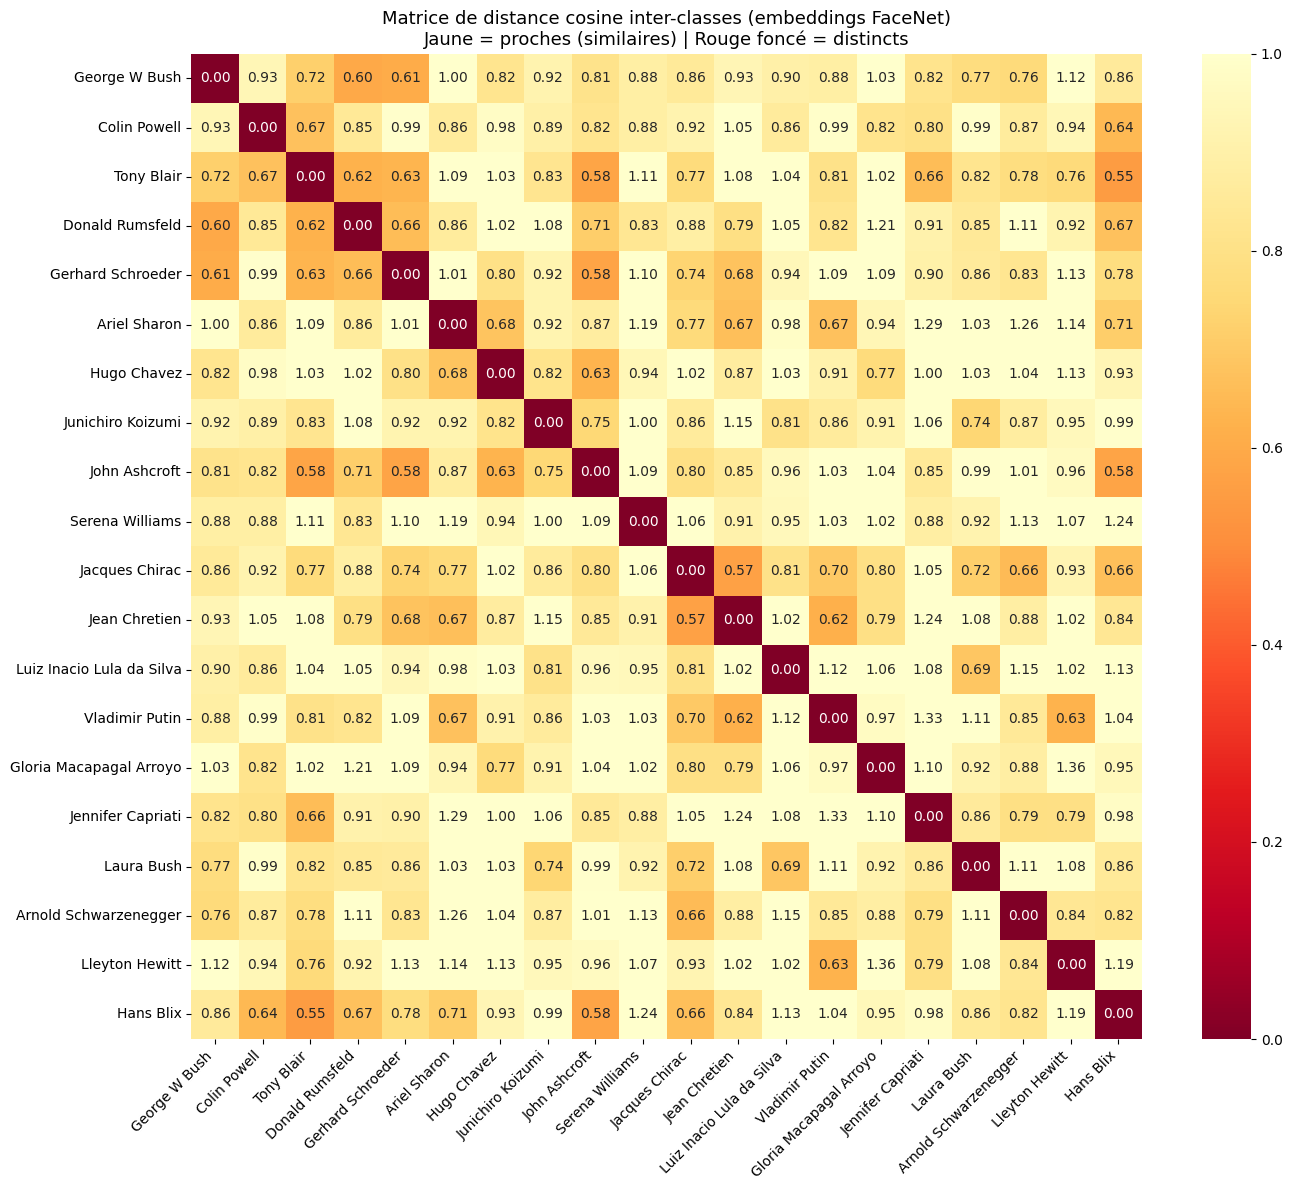


🔍 Top-5 paires les plus proches (risque de confusion) :
   Tony Blair ↔ Hans Blix : distance = 0.550
   Jacques Chirac ↔ Jean Chretien : distance = 0.567
   Gerhard Schroeder ↔ John Ashcroft : distance = 0.577
   John Ashcroft ↔ Hans Blix : distance = 0.578
   Tony Blair ↔ John Ashcroft : distance = 0.582


In [ ]:
# ── Cellule 12 : Matrice de distance cosine inter-classes ─────────────
# Pour chaque paire de personnes (top-20) :
#   Distance ≈ 0 (jaune) → embeddings proches → personnes similaires → risque de confusion
#   Distance ≈ 1 (rouge) → embeddings éloignés → personnes bien distinctes

from sklearn.preprocessing import normalize as sk_normalize

top20_enc   = [enc for enc, _ in Counter(y_test).most_common(20)]
top20_names = [le.classes_[e].replace('_',' ') for e in top20_enc]

# Centroïde L2-normalisé de chaque classe dans le test set
centroids = np.array([
    X_test[y_test == enc].mean(axis=0)
    for enc in top20_enc
])
centroids = sk_normalize(centroids)

# Distance cosine = 1 - produit scalaire (vecteurs déjà normalisés)
dist_matrix = 1 - centroids @ centroids.T
np.fill_diagonal(dist_matrix, 0)

plt.figure(figsize=(14, 12))
sns.heatmap(dist_matrix, annot=True, fmt='.2f',
            xticklabels=top20_names, yticklabels=top20_names,
            cmap='YlOrRd_r', vmin=0, vmax=1)
plt.title(
    "Matrice de distance cosine inter-classes (embeddings FaceNet)\n"
    "Jaune = proches (similaires) | Rouge foncé = distincts",
    fontsize=13
)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Top-5 paires les plus proches = confusions potentielles
pairs = []
for i in range(len(top20_enc)):
    for j in range(i+1, len(top20_enc)):
        pairs.append((dist_matrix[i,j], top20_names[i], top20_names[j]))
pairs.sort()
print("\n Top-5 paires les plus proches (risque de confusion) :")
for dist, n1, n2 in pairs[:5]:
    print(f"   {n1} ↔ {n2} : distance = {dist:.3f}")

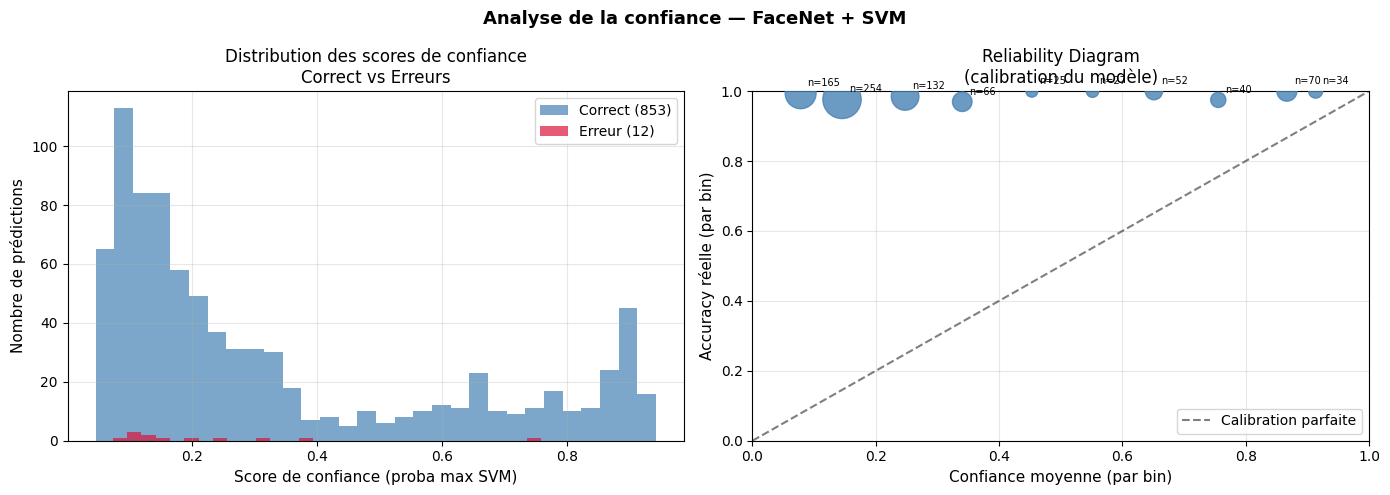


📊 Confiance moy. — Correct : 0.333
   Confiance moy. — Erreur  : 0.228


In [ ]:
# ── Cellule 13 : Distribution des scores de confiance ─────────────────
# Confiance = probabilité max donnée par le SVM (predict_proba)
# Bon modèle : très confiant sur les bons, hésitant sur les erreurs

conf_scores = clf.predict_proba(X_test).max(axis=1)
correct      = (y_pred == y_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ① Histogramme correct vs erreur
axes[0].hist(conf_scores[correct],  bins=30, alpha=0.7,
             color='steelblue', label=f'Correct ({correct.sum()})')
axes[0].hist(conf_scores[~correct], bins=30, alpha=0.7,
             color='crimson',   label=f'Erreur ({(~correct).sum()})')
axes[0].set_xlabel('Score de confiance (proba max SVM)', fontsize=11)
axes[0].set_ylabel('Nombre de prédictions', fontsize=11)
axes[0].set_title('Distribution des scores de confiance\nCorrect vs Erreurs', fontsize=12)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# ② Reliability diagram : confiance calibrée ?
# Dans un modèle parfait : accuracy réelle ≈ confiance moyenne par bin
bins = np.linspace(0, 1, 11)
bin_acc, bin_conf, bin_count = [], [], []
for b_low, b_high in zip(bins[:-1], bins[1:]):
    mask_b = (conf_scores >= b_low) & (conf_scores < b_high)
    if mask_b.sum() > 0:
        bin_acc.append(correct[mask_b].mean())
        bin_conf.append(conf_scores[mask_b].mean())
        bin_count.append(mask_b.sum())

axes[1].plot([0,1], [0,1], 'k--', alpha=0.5, label='Calibration parfaite')
axes[1].scatter(bin_conf, bin_acc,
                s=[c*3 for c in bin_count],
                color='steelblue', alpha=0.8, zorder=3)
for bc, ba, bn in zip(bin_conf, bin_acc, bin_count):
    axes[1].annotate(f'n={bn}', (bc, ba),
                     textcoords='offset points', xytext=(5,5), fontsize=7)
axes[1].set_xlabel('Confiance moyenne (par bin)', fontsize=11)
axes[1].set_ylabel('Accuracy réelle (par bin)', fontsize=11)
axes[1].set_title('Reliability Diagram\n(calibration du modèle)', fontsize=12)
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)

plt.suptitle('Analyse de la confiance — FaceNet + SVM',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n Confiance moy. — Correct : {conf_scores[correct].mean():.3f}")
print(f"   Confiance moy. — Erreur  : {conf_scores[~correct].mean():.3f}")